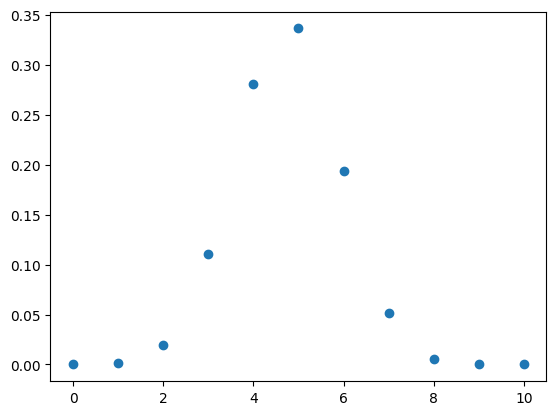

In [1]:
# Modelling N coin tosses (Discrete Modelling)
N = 20

# Generate Space
def gen_space(n: int) -> set[str]:
    if n == 1:
        return {"H", "T"}
    else:
        prev = gen_space(n - 1)
        return {s + t for s in prev for t in {"H", "T"}}
sample_space = gen_space(N)

# Fair for now
def Pr(outcome: str) -> float:
    return 1 / (2**len(outcome))

# Random Variable -- Num Heads then Tails
def X(outcome: str) ->  float:
    return outcome.count("HT")
ranX = sorted({X(o) for o in sample_space})

# Distribution - PMF
def f(x: float) -> float:
    if x in ranX:
        return sum(Pr(outcome) for outcome in sample_space if X(outcome) == x)
    else:
        return 0.0
data = [f(x) for x in ranX]


# Vis
from matplotlib import pyplot as plt
plt.scatter(ranX, data)
plt.show()


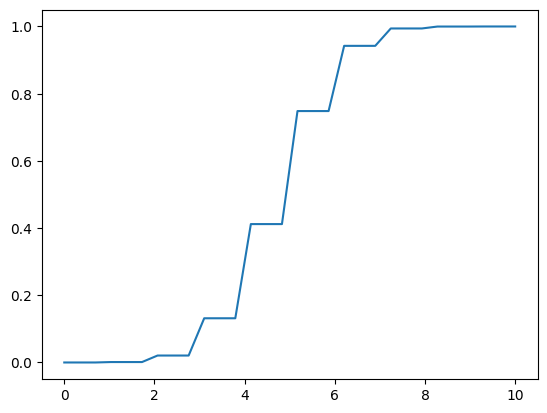

In [5]:
def F(x: float) -> float:
    return sum(f(y) for y in ranX if y <= x)

def Q(p: float) -> float:
    if p >= 1.0 or p <= 0.0:
        raise ValueError
    else:
        prev = -1
        for x in reversed(ranX):
            if F(x) < p:
                return prev
            else:
                prev = x

import numpy as np
ln = list(np.linspace(0, 10, 30))
Fs = [F(x) for x in ln]
plt.plot(ln, Fs)
plt.show()